(3624, 34)
   section   season  gameweek  match_id                  date_label  \
0  results  2025/26       1.0   84330.0  Thu 28 Aug 2025, 17:05 BST   
1  results  2025/26       1.0   84328.0  Thu 28 Aug 2025, 19:00 BST   
2  results  2025/26       1.0   84329.0  Thu 28 Aug 2025, 19:00 BST   
3  results  2025/26       1.0   84332.0  Fri 29 Aug 2025, 16:50 BST   
4  results  2025/26       1.0   84333.0  Fri 29 Aug 2025, 19:00 BST   

     kickoff_ms   home_team   away_team  home_goals  away_goals  ... lost  \
0  1.756397e+12       Damac    Al Hazem         1.0         1.0  ...  NaN   
1  1.756404e+12     Al Ahli   Neom S.C.         1.0         0.0  ...  NaN   
2  1.756404e+12  Al Ettifaq  Al Kholood         2.0         1.0  ...  NaN   
3  1.756483e+12    Al Hilal   Al Riyadh         2.0         0.0  ...  NaN   
4  1.756490e+12   Al Shabab  Al Khaleej         1.0         4.0  ...  NaN   

  goals_for  goals_against goal_diff points ppg win_pct  avg_scored  \
0       NaN            NaN  

C:\Users\sheed\AppData\Local\Temp\ipykernel_27184\3245988138.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="result", data=df, palette="Set2")


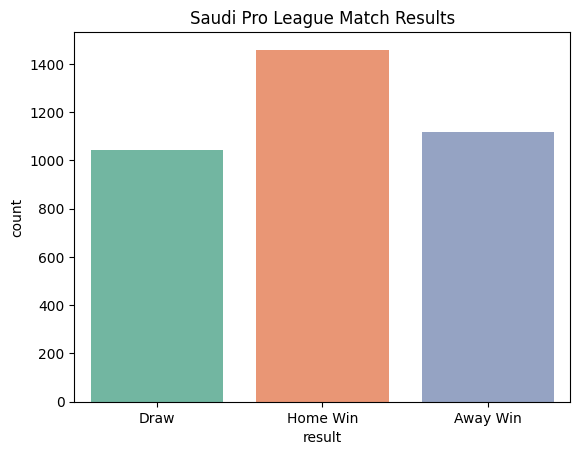

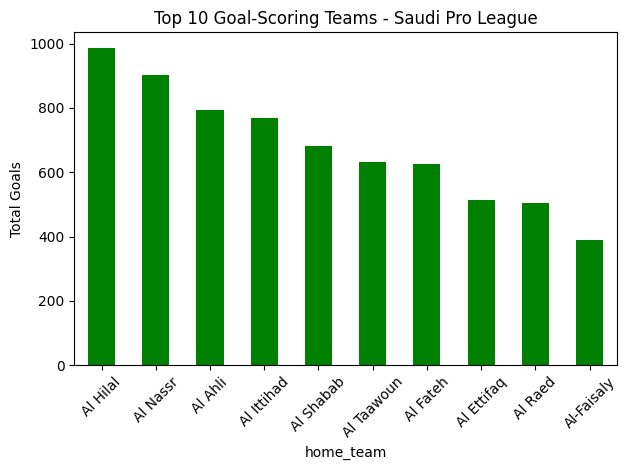

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\data\\spl_matches.csv")

# Basic info
print(df.shape)
print(df.head())
print(df.isnull().sum())

# Add result column
def get_result(row):
    if row["home_goals"] > row["away_goals"]:
        return "Home Win"
    elif row["home_goals"] < row["away_goals"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(get_result, axis=1)

# Plot result distribution
sns.countplot(x="result", data=df, palette="Set2")
plt.title("Saudi Pro League Match Results")
plt.savefig("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\images\\result_distribution.png")
plt.show()

# Top scoring teams
home_goals = df.groupby("home_team")["home_goals"].sum()
away_goals = df.groupby("away_team")["away_goals"].sum()
total_goals = (home_goals + away_goals).sort_values(ascending=False)

total_goals.head(10).plot(kind="bar", color="green")
plt.title("Top 10 Goal-Scoring Teams - Saudi Pro League")
plt.ylabel("Total Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\images\\top_scorers.png")
plt.show()